# NutriPredict Congo — Modélisation Machine Learning
**Auteur :** MPOY Schekina Lutte-de-vie  
**Date :** 29/07/2026  
**Notebook :** 04 / 05 — Pipeline de classification du stunting  

---

## Objectif de ce notebook

Construire et évaluer un modèle capable de prédire le risque
de stunting à partir des facteurs socio-démographiques
identifiés en Phase 3 (EDA).

Les étapes dans l'ordre :
1. Chargement du dataset propre (congo_clean.csv)
2. Sélection des features et séparation train/test
3. Construction du Pipeline sklearn (imputation, encodage, scaling)
4. Modèle de référence — Régression Logistique
5. Évaluation avec métriques adaptées au déséquilibre
6. Modèle de comparaison — Random Forest
7. Analyse de feature importance
8. Comparaison finale et choix du modèle retenu

## Règle appliquée dans ce notebook

Le split train/test est fait AVANT tout prétraitement
statistique (imputation, encodage, scaling). Ces étapes
sont intégrées dans un Pipeline sklearn qui apprend
uniquement sur le train set.

## 1. Chargement des données et sélection des features

On charge congo_clean.csv produit en Phase 2 pas les
colonnes _label créées en Phase 3, qui étaient uniquement
pour la lisibilité des graphiques.

In [1]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

# Chargement du dataset propre
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
CHEMIN_DATA = os.path.join(BASE_DIR, 'data', 'processed', 'congo_clean.csv')

df = pd.read_csv(CHEMIN_DATA)

print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\nColonnes disponibles :")
print(df.columns.tolist())

# On selection les features pour le modèle
# On exclut : hw70/hw71/hw72 (auraient définit directement la cible, ce qui constituerait une fuite),
# ainsi que : v001/v002/cle_menage (sont des identifiants, pas des features prédictives)
FEATURES = ['hv025', 'hv270', 'hv201', 'hv205', 'hv206', 'hv219', 'b4', 'b8', 'bord']
CIBLE    = 'stunting'

X = df[FEATURES].copy()
y = df[CIBLE].copy()

print(f"\nFeatures retenues ({len(FEATURES)}) : {FEATURES}")
print(f"Cible : {CIBLE}")
print(f"\nDistribution de la cible :")
print(y.value_counts(normalize=True).round(3) * 100)

Dataset chargé : 4475 lignes, 16 colonnes

Colonnes disponibles :
['v001', 'v002', 'hw70', 'hw71', 'hw72', 'b4', 'b8', 'bord', 'cle_menage', 'hv025', 'hv270', 'hv201', 'hv205', 'hv206', 'hv219', 'stunting']

Features retenues (9) : ['hv025', 'hv270', 'hv201', 'hv205', 'hv206', 'hv219', 'b4', 'b8', 'bord']
Cible : stunting

Distribution de la cible :
stunting
0    73.3
1    26.7
Name: proportion, dtype: float64


## 2. Séparation des données d'entraînement et de test

Avant tout prétraitement statistique, les données sont séparées en un ensemble d'entraînement (*train*) et un ensemble de test (*test*).

Cette étape est essentielle pour éviter la **fuite de données (data leakage)**. En effet, le modèle ne doit jamais avoir accès aux informations provenant des données de test, même indirectement, par exemple via une moyenne, un écart-type ou un encodage calculé sur l'ensemble complet des données.

**Configuration retenue :**
- **80 %** des données pour l'entraînement ;
- **20 %** des données pour le test ;
- `stratify=y` afin de conserver la même proportion de cas de retard de croissance (≈ 26,7 %) dans les deux ensembles, ce qui est particulièrement important en présence d'un déséquilibre des classes.

In [2]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Train : {X_train.shape[0]} lignes, {X_train.shape[0]/len(X)*100:.1f}%")
print(f"Test : {X_test.shape[0]} lignes, {X_test.shape[0]/len(X)*100:.1f}%")

print("\n ==== Vérification de la stratification ====")
print(f"Proportion stunting dans le train : {y_train.mean()*100:.1f}%")
print(f"Proportion stunting dans le test : {y_test.mean()*100:.1f}%")


Train : 3580 lignes, 80.0%
Test : 895 lignes, 20.0%

 ==== Vérification de la stratification ====
Proportion stunting dans le train : 26.8%
Proportion stunting dans le test : 26.7%


## 3. Construction du Pipeline sklearn

Le Pipeline enchaîne trois étapes automatiquement, apprises
uniquement sur le train set puis appliquées telles quelles
au test set — c'est le mécanisme concret qui empêche la
fuite de données.

Trois traitements nécessaires :
1. Imputation — au cas où il resterait des valeurs manquantes
2. Encodage — les variables catégorielles (hv025, hv219, b4...)
   doivent être transformées en format numérique compatible avec sklearn
3. Mise à l'échelle — uniformise les échelles entre variables
   (bord va de 1 à 10+, hv270 de 1 à 5)

On sépare les features en deux groupes car elles ne
nécessitent pas le même traitement :
- Variables catégorielles → imputation + OneHotEncoder
- Variables numériques continues (b8) → imputation + scaling

In [3]:
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Séparation des types de variables
features_categorielles = ["hv025","hv270","hv201","hv205","hv206","hv219","b4","bord"]
features_numeriques = ["b8"]

# Pipeline pour les variables catégorielles 
transformateur_categoriel = Pipeline(steps=[
    ("imputation",SimpleImputer(strategy = "most_frequent")),
    ("encodage",OneHotEncoder(handle_unknown = "ignore"))
])

# Pipeline pour les variables numériques 
transformateur_numerique = Pipeline(steps=[
    ("imputation",SimpleImputer(strategy ="median")),
    ("scaling",StandardScaler())
])

# Combinaison des deux dans un ColumnTransformer
preprocesseur = ColumnTransformer(transformers=[
    ("cat",transformateur_categoriel,features_categorielles),
    ("num",transformateur_numerique,features_numeriques)
])

print("Preprocesseur construit")
print(f" Variables catégorielles({len(features_categorielles)}): {features_categorielles}")
print(f" Variables numériques({len(features_numeriques)}): {features_numeriques}")

Preprocesseur construit
 Variables catégorielles(8): ['hv025', 'hv270', 'hv201', 'hv205', 'hv206', 'hv219', 'b4', 'bord']
 Variables numériques(1): ['b8']


## 4. Modèle de référence — Régression Logistique

La régression logistique est le modèle de départ standard
pour la classification binaire — simple, interprétable,
rapide à entraîner. On l'utilise comme référence (baseline)
avant de tester des modèles plus complexes.

class_weight='balanced' compense le déséquilibre de classes
(26.7% de stunting) en donnant plus de poids aux erreurs
sur la classe minoritaire pendant l'entraînement — décision
prise en Phase 2 suite à l'analyse de la distribution.

In [4]:
from sklearn.linear_model import LogisticRegression 

# Pipeline complet: preprocesseur + modèle
pipeline_loreg = Pipeline(steps=[
    ("preprocesseur",preprocesseur),
    ("modele",LogisticRegression(
        class_weight ="balanced",
        random_state =42,
        max_iter = 1000
    ))
])

# Entrainement du modèle 
pipeline_loreg.fit(X_train,y_train)
print("Modèle entrainé sur le train set")
print(f" Nombre d'observations : d'entrainement : {len(X_train)}")


Modèle entrainé sur le train set
 Nombre d'observations : d'entrainement : 3580


## 5. Évaluation du modèle — métriques adaptées au déséquilibre

L'accuracy seule est trompeuse sur un problème déséquilibré. Un modèle qui prédit toujours "0" (pas de stunting) obtiendrait 73.3% d'accuracy sans avoir rien appris d'utile.

Métriques utilisées :
- Precision : parmi les enfants prédits "à risque", combien
  le sont réellement ?
- Recall : parmi les enfants réellement à risque, combien
  le modèle en détecte ?
- F1-score : moyenne harmonique entre precision et recall
- ROC-AUC : capacité globale du modèle à distinguer les
  deux classes, indépendamment du seuil de décision

Dans ce contexte de santé publique, le recall est
particulièrement important : rater un enfant réellement
à risque (faux négatif) est plus coûteux que classer par
erreur un enfant sain comme à risque (faux positif).

In [5]:
from sklearn.metrics import ( classification_report, confusion_matrix, roc_auc_score,f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
# Prédiction sur le test set 
y_pred = pipeline_loreg.predict(X_test)
y_proba = pipeline_loreg.predict_proba(X_test)[:,1]

# Métriques de performance 
precision = precision_score(y_test,y_pred)
recall= recall_score(y_test,y_pred)
f1= f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_proba)

print("=== Métriques — Régression Logistique ====")
print(f"Precision : {precision:.3f}")
print(f"Recall : {recall:.3f}")
print(f"F1-score : {f1:.3f}")   
print(f"ROC-AUC : {roc_auc:.3f}")


print(f"\n=== Rapport de classification complet ====")
print(classification_report(y_test,y_pred, target_names =
                            ["Normal(0)","Stunting(1)"]))


print(f"==== Matrice de confusion ====")
cm= confusion_matrix(y_test,y_pred)
print(f"                       Prédit Normal(0)   Prédit Stunting(1)")
print(f" Réel Normal(0)        {cm[0][0]:>6}       {cm[0][1]:>6}")
print(f" Réel  stunting(1)      {cm[1][0]:>6}      {cm[1][1]:>6}")


=== Métriques — Régression Logistique ====
Precision : 0.328
Recall : 0.649
F1-score : 0.436
ROC-AUC : 0.623

=== Rapport de classification complet ====
              precision    recall  f1-score   support

   Normal(0)       0.80      0.52      0.63       656
 Stunting(1)       0.33      0.65      0.44       239

    accuracy                           0.55       895
   macro avg       0.56      0.58      0.53       895
weighted avg       0.68      0.55      0.58       895

==== Matrice de confusion ====
                       Prédit Normal(0)   Prédit Stunting(1)
 Réel Normal(0)           339          317
 Réel  stunting(1)          84         155


## 6. Visualisation de la matrice de confusion

Le tableau texte de la matrice de confusion est difficile
à interpréter rapidement. Une heatmap seaborn permet de
visualiser immédiatement où le modèle se trompe, avec un
code couleur qui met en évidence les cases importantes.

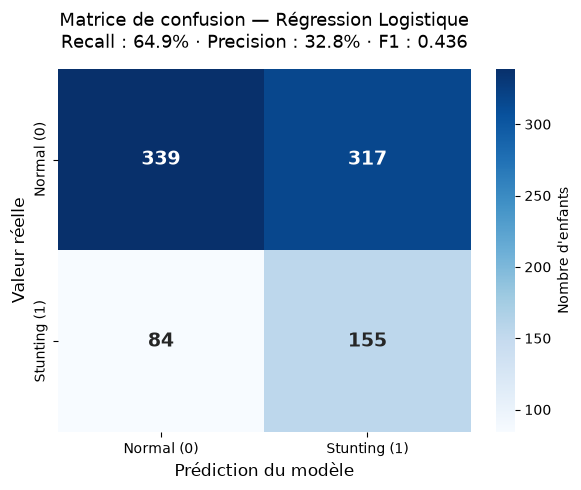

✓ Graphique sauvegardé


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal (0)', 'Stunting (1)'],
    yticklabels=['Normal (0)', 'Stunting (1)'],
    cbar_kws={'label': "Nombre d'enfants"},
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
    ax=ax
)

ax.set_xlabel('Prédiction du modèle', fontsize=12)
ax.set_ylabel('Valeur réelle', fontsize=12)
ax.set_title(
    'Matrice de confusion — Régression Logistique\n'
    f'Recall : {recall:.1%} · Precision : {precision:.1%} · F1 : {f1:.3f}',
    fontsize=13, pad=15
)

plt.tight_layout()
plt.savefig(
    os.path.join(BASE_DIR, 'outputs', '07_matrice_confusion_logreg.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ Graphique sauvegardé")

## 7. Modèle de comparaison — Random Forest

Le Random Forest est un modèle plus complexe qui combine
plusieurs arbres de décision. Contrairement à la régression
logistique, il peut capturer des relations non linéaires
entre les variables — potentiellement utile ici vu que
l'EDA a montré une relation non linéaire entre l'âge et
le stunting (pic à 2 ans, pas une tendance simplement
croissante ou décroissante).

On garde la même logique : class_weight='balanced' pour
gérer le déséquilibre de classes, même Pipeline de
prétraitement, même train/test split pour une comparaison
équitable.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline complet avec Random Forest
pipeline_rf = Pipeline(steps=[
    ("preprocesseur", preprocesseur),
    ("modele", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ))
])

# Entrainement
pipeline_rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:,1]

# Métriques 
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=== Métriques — Random Forest ====")
print(f"Precision :{precision_rf:.3f}")
print(f"Recall : {recall_rf:.3f}")
print(f"F1-score : {f1_rf:.3f}")
print(f"ROC-AUC : {roc_auc_rf:.3f}")

=== Métriques — Random Forest ====
Precision :0.371
Recall : 0.678
F1-score : 0.479
ROC-AUC : 0.655


## 8. Comparaison visuelle des deux modèles

On compare les deux modèles avec deux visualisations :
- Un graphique en barres des quatre métriques côte à côte
- Les courbes ROC superposées, pour voir la capacité de
  discrimination sur toute la plage de seuils possibles

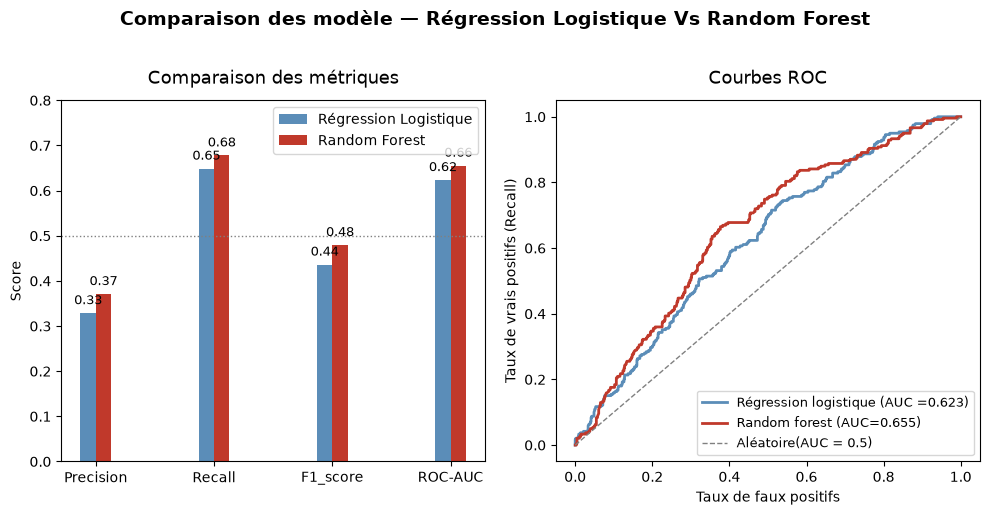

✓ Graphique sauvegardé


In [8]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1,2, figsize=(10,5))

# ---Graphique de gauche : comparaison des métriques
metriques = ["Precision","Recall","F1_score","ROC-AUC"]
valeurs_loreg = [precision,recall,f1,roc_auc]
valeurs_rf = [precision_rf,recall_rf,f1_rf,roc_auc_rf]
x= np.arange(len(metriques))
largeur= 0.13

axes[0].bar(x - largeur/2, valeurs_loreg, width=largeur, label="Régression Logistique",color="#5B8DB8")
axes[0].bar(x + largeur/2, valeurs_rf, width=largeur, label="Random Forest", color ="#C0392B")

axes[0].set_xticks(x)
axes[0].set_xticklabels(metriques)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0,0.8)
axes[0].set_title("Comparaison des métriques",fontsize=13,pad=12)
axes[0].legend(fontsize=10)
axes[0].axhline(y=0.5,color="grey",linestyle=":",linewidth=1)

for i, (vl,vr) in enumerate(zip(valeurs_loreg,valeurs_rf)):
    axes[0].text(i - largeur/2, vl + 0.02, f'{vl:.2f}', ha='center', fontsize=9)
    axes[0].text(i + largeur/2, vr+0.02, f'{vr:.2f}', ha='center', fontsize=9)


# --- Graphique de droite : courbe Roc ---
fpr_logreg, tpr_logreg,_ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test,y_proba_rf)

axes[1].plot(fpr_logreg,tpr_logreg,color='#5B8DB8',linewidth=2,
             label =f"Régression logistique (AUC ={roc_auc:.3f})")
axes[1].plot(fpr_rf, tpr_rf,color ='#C0392B', linewidth=2 , label=f"Random forest (AUC={roc_auc_rf:.3f})")

axes[1].plot([0,1],[0,1], color ="grey", linestyle ="--",linewidth =1, label="Aléatoire(AUC = 0.5)")

axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs (Recall)")
axes[1].set_title("Courbes ROC",fontsize=13,pad=12)
axes[1].legend(fontsize=9,loc="lower right")

fig.suptitle("Comparaison des modèle — Régression Logistique Vs Random Forest", fontsize=14,fontweight="bold",y=1.02)

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR,"outputs", "08_comparaison_modeles.png"),
    dpi=150, bbox_inches="tight"
)



plt.show()
print("✓ Graphique sauvegardé")




## 9. Analyse de la feature importance (Random Forest)

L'EDA en Phase 3 a montré des écarts univariés pour chaque
facteur pris séparément. Mais on avait aussi noté une limite
importante : ces facteurs sont probablement corrélés entre eux
(un ménage pauvre cumule souvent plusieurs désavantages).

La feature importance du Random Forest répond à cette limite :
elle mesure la contribution de chaque variable à la prédiction
UNE FOIS que le modèle a pris en compte toutes les autres
variables simultanément. C'est la réponse multivariée qu'on
avait annoncée à la fin du notebook 03.

In [14]:
# Récupération des noms de features après  OneHotEncoding 

noms_features_cat = (pipeline_rf.named_steps["preprocesseur"]
    .named_transformers_["cat"]
    .named_steps["encodage"]
    .get_feature_names_out(features_categorielles)
)

noms_features_num = np.array(features_numeriques)

noms_features_complets = np.concatenate([noms_features_cat,noms_features_num])

# Récupération des importances 
importances = pipeline_rf.named_steps["modele"].feature_importances_

# Dataframe pour tri et visualisation 
df_importance= pd.DataFrame({
    "feature":noms_features_complets,
    "importance":importances
}).sort_values(by="importance",ascending= False)

print("=== Top15 features les plus importantes ===")
print(df_importance.head(15).to_string(index=False))


=== Top15 features les plus importantes ===
 feature  importance
      b8    0.233639
 hv206_0    0.057524
 hv206_1    0.057348
 hv270_1    0.048381
    b4_2    0.029450
 hv270_5    0.028148
    b4_1    0.027322
 hv025_1    0.025909
 hv270_2    0.024192
 hv025_2    0.023746
hv205_23    0.021944
  bord_1    0.021616
hv201_13    0.021464
hv205_31    0.020702
hv205_22    0.019550


## 10. Visualisation de la feature importance

On regroupe les catégories encodées par variable d'origine
pour une lecture plus claire.

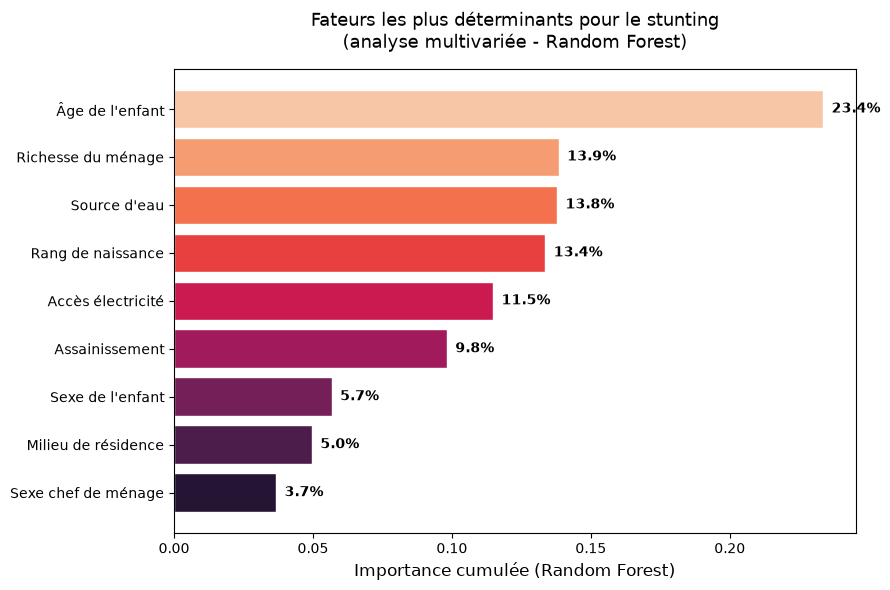

✓ Graphique sauvegardé

 === Importance cumulée par variable ===
variable_origine
Âge de l'enfant        23.4
Richesse du ménage     13.9
Source d'eau           13.8
Rang de naissance      13.4
Accès électricité      11.5
Assainissement          9.8
Sexe de l'enfant        5.7
Milieu de résidence     5.0
Sexe chef de ménage     3.7
Name: importance, dtype: float64


In [21]:
# Regroupement des importances par feature d'origine 

mapping_features = {
    'b8': 'Âge de l\'enfant',
    'hv206': 'Accès électricité',
    'hv270': 'Richesse du ménage',
    'b4': 'Sexe de l\'enfant',
    'hv025': 'Milieu de résidence',
    'hv205': 'Assainissement',
    'bord': 'Rang de naissance',
    'hv201': 'Source d\'eau',
    'hv219': 'Sexe chef de ménage'
}

def extraire_variable_origine(nom_feature):
    for prefix in mapping_features:
        if nom_feature.startswith(prefix):
            return mapping_features[prefix]
    return nom_feature

df_importance["variable_origine"] = df_importance["feature"].apply(extraire_variable_origine)

importance_groupee = (df_importance.groupby("variable_origine")["importance"]
                      .sum()
                      .sort_values(ascending=False))

# Graphique 

fig,ax = plt.subplots(figsize=(9,6))

colors_grad = sns.color_palette("rocket_r",len(importance_groupee))

bars = ax.barh(
    importance_groupee.index[::-1],
    importance_groupee[::-1],
    color=colors_grad[::-1],
    edgecolor ="white"
)

ax.set_xlabel("Importance cumulée (Random Forest)",fontsize=12)
ax.set_title(
    "Fateurs les plus déterminants pour le stunting\n"
    "(analyse multivariée - Random Forest)",
    fontsize=13, pad=15
)

for i, v in enumerate(importance_groupee.values[::-1]):
    ax.text(v+0.003, i, f"{v*100:.1f}%",va="center",fontsize=10,fontweight="bold")

plt.tight_layout()
plt.savefig(
    os.path.join(BASE_DIR,"outputs","09_feature_importance.png"),
    dpi=150,bbox_inches="tight"
)
plt.show()
print("✓ Graphique sauvegardé")
print("\n === Importance cumulée par variable ===")
print((importance_groupee*100).round(1))


## 11. Synthèse et choix du modèle retenu

### Comparaison des modèles

| Métrique | Régression Logistique | Random Forest |
|---|---|---|
| Precision | 0.328 | 0.371 |
| Recall | 0.649 | 0.678 |
| F1-score | 0.436 | 0.479 |
| ROC-AUC | 0.623 | 0.655 |

**Modèle retenu : Random Forest** — supérieur sur les 4 métriques,
avec l'avantage additionnel de fournir une feature importance
interprétable, essentielle pour la logique de ciblage visée
par ce projet.

### Facteurs les plus déterminants (analyse multivariée)

1. Âge de l'enfant (23.4%) — confirme la fenêtre des 1000 jours
2. Richesse du ménage (13.9%)
3. Source d'eau potable (13.8%)
4. Rang de naissance (13.4%) — sous-estimé par l'EDA univariée
5. Accès à l'électricité (11.5%)

### Limites du modèle

- Performances modestes (F1=0.479, ROC-AUC=0.655) : les 9 variables
  disponibles n'expliquent qu'une partie du phénomène. D'autres
  facteurs non mesurés (alimentation, santé maternelle, maladies
  infantiles) jouent probablement un rôle important.
- Le déséquilibre de classes limite la precision : le modèle
  privilégie volontairement le recall (détecter les cas à risque)
  au prix de plus de faux positifs — choix assumé pour un usage
  de santé publique où rater un cas réel est plus coûteux.
- Dataset limité à un seul pays et une seule période (Congo 2011-12) :
  la généralisation à d'autres contextes n'est pas garantie.